<br>

<br>

# Autoscout EDA

## EDA for Car Price Prediction

<br>

<br>! Hello everyone ! <br><br>
This dataset contains many features of 9 different car models.
In this project we are going to prepare this dataset to provide an appropriate input to the ML models.<br>
Thus the steps we are going to follow ;
- Fix the corrupted data formats
- Handle with outliers and missing values.
- Drop the columns/rows you determined unnecessary as a result of your analysis.

<br>
<br> Before start analyzing first let's import the libraries we might use for further steps.

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

<br>

In [2]:
df = pd.read_json("scout_car.json", lines = True)

Even though we ussually work on a csv file, this once we are going to be working on a json file. The way that we import it is almost the same with csv file. Only the difference is "lines" parameter.

<br>

- To get an idea of what the data looks like, let's have a look at that by getting some random samples.<br><br>

- I am going to get the tranpose of it to see all the columns.

In [3]:
df.sample(3).T

,14288,9642,6116
url,https://www.autoscout24.com//offers/renault-cl...,https://www.autoscout24.com//offers/opel-corsa...,https://www.autoscout24.com//offers/opel-astra...
make_model,Renault Clio,Opel Corsa,Opel Astra
short_description,LIMITED 2018 TCe 75 Klima/LED,"E Edition 1,4 Automatik Klima",ST 1.6 CDTI Business Klima ZV Tempomat
body_type,Sedans,Compact,Station wagon
price,9999,14575,10490
vat,VAT deductible,VAT deductible,None
km,10 km,50 km,"90,000 km"
registration,01/2019,09/2018,08/2016
prev_owner,1 previous owner,None,2 previous owners
kW,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            15919 non-null  object 
 1   make_model                     15919 non-null  object 
 2   short_description              15873 non-null  object 
 3   body_type                      15859 non-null  object 
 4   price                          15919 non-null  int64  
 5   vat                            11406 non-null  object 
 6   km                             15919 non-null  object 
 7   registration                   15919 non-null  object 
 8   prev_owner                     9091 non-null   object 
 9   kW                             0 non-null      float64
 10  hp                             15919 non-null  object 
 11  Type                           15917 non-null  object 
 12  Previous Owners                9279 non-null  

In [5]:
df.isnull().sum()

url                                  0
make_model                           0
short_description                   46
body_type                           60
price                                0
vat                               4513
km                                   0
registration                         0
prev_owner                        6828
kW                               15919
hp                                   0
Type                                 2
Previous Owners                   6640
Next Inspection                  12384
Inspection new                   11987
Warranty                          5420
Full Service                      7704
Non-smoking Vehicle               8742
null                                 0
Make                                 0
Model                                0
Offer Number                      3175
First Registration                1597
Body Color                         597
Paint Type                        5772
Body Color Original      

<br>I am not happy to say that but this dataset is __chaotic__ !! We have got a lot to do, better to get started.<br><br>

In [6]:
df1 = df.copy()

#### Dropping the column which have more than %50 null values.

In [7]:
df1.drop('kW', axis = 1, inplace = True)
df1.drop('Next Inspection', axis = 1, inplace = True)
df1.drop('Inspection new', axis = 1, inplace = True)
df1.drop('Non-smoking Vehicle', axis = 1, inplace = True)
df1.drop('null', axis = 1, inplace = True)
df1.drop('Model Code', axis = 1, inplace = True)
df1.drop('Emission Label', axis = 1, inplace = True)
df1.drop('Full Service', axis = 1, inplace = True)
df1.drop('Electricity consumption', axis = 1, inplace = True)
df1.drop('Last Service Date', axis = 1, inplace = True)
df1.drop('Other Fuel Types', axis = 1, inplace = True)
df1.drop('Availability', axis = 1, inplace = True)
df1.drop('Last Timing Belt Service Date', axis = 1, inplace = True)
df1.drop('Available from', axis = 1, inplace = True)

<br>

- Let's shoot a glance to each column one by one.

In [8]:
df1.columns

Index(['url', 'make_model', 'short_description', 'body_type', 'price', 'vat',
       'km', 'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### Url

In [9]:
df1.drop('url', axis = 1, inplace = True)

In [10]:
df1.columns

Index(['make_model', 'short_description', 'body_type', 'price', 'vat', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### make_model

In [11]:
df1.make_model.value_counts(dropna = False)

Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: make_model, dtype: int64

In [12]:
df1.rename(columns={'make_model':'Make_Model'}, inplace = True)

### short_description

In [13]:
df1.drop('short_description', axis = 1, inplace = True)

In [14]:
df1.columns

Index(['Make_Model', 'body_type', 'price', 'vat', 'km', 'registration',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'First Registration', 'Body Color',
       'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### body_type

In [15]:
df1.body_type.value_counts(dropna = False)

Sedans           7903
Station wagon    3553
Compact          3153
Van               783
Other             290
Transporter        88
NaN                60
Off-Road           56
Coupe              25
Convertible         8
Name: body_type, dtype: int64

In [16]:
df1.rename(columns={'body_type':'Body_Type'}, inplace = True)

### price

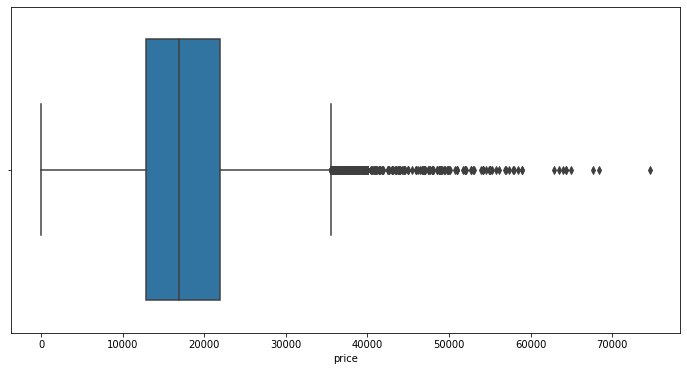

In [17]:
plt.figure(figsize = (12,6))
sns.boxplot(df1.price);

In [18]:
df1.price.sort_values().head(10)

8594       13
8828      120
6066      255
8829      331
8827     4950
8825     4990
8826     5250
8824     5300
13770    5445
8823     5450
Name: price, dtype: int64

In [19]:
df1.price.sort_values(ascending=False).head(10)

3648     74600
15826    68320
3649     67600
3587     64900
15828    64332
15831    64298
3595     63900
15833    63477
3590     62900
3594     58990
Name: price, dtype: int64

In [20]:
df1.rename(columns={'price':'Price'}, inplace = True)

### vat

In [21]:
df1.vat.value_counts(dropna = False)

VAT deductible      10980
NaN                  4513
Price negotiable      426
Name: vat, dtype: int64

In [22]:
def vat_bool (i):
        if i == "VAT deductible":
             return True
        else :
            return False

In [23]:
df1.vat = df1.vat.apply(vat_bool)

In [24]:
df1.rename(columns={'vat':'Vat_Deductible'}, inplace = True)

In [25]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### km

In [26]:
df1.km.value_counts()

10 km        1045
- km         1024
1 km          367
5 km          170
50 km         148
             ... 
131 km          1
16,280 km       1
28,023 km       1
50,505 km       1
26,525 km       1
Name: km, Length: 6690, dtype: int64

In [27]:
df1.rename(columns={'km':'Km'}, inplace = True)

In [28]:
df1.Km = df1.Km.astype('str').replace('- km', np.nan)
df1.Km  = df1.Km.str.strip(" km")
df1.Km = df1.Km.str.replace(",", "")
df1.Km = df1.Km.astype(float)

In [29]:
df1.Km

0        56013.0
1        80000.0
2        83450.0
3        73000.0
4        16200.0
          ...   
15914        NaN
15915     9900.0
15916       15.0
15917       10.0
15918        NaN
Name: Km, Length: 15919, dtype: float64

### registration & First Registration

In [30]:
df1.registration.value_counts()

-/-        1597
03/2018     695
02/2019     585
05/2018     572
03/2019     543
04/2018     541
01/2019     541
02/2018     539
03/2016     536
04/2016     532
06/2018     532
01/2018     511
04/2019     506
02/2016     472
03/2017     471
05/2016     459
06/2016     452
05/2019     440
06/2017     409
05/2017     404
07/2018     396
04/2017     380
01/2016     376
02/2017     368
01/2017     306
08/2018     285
06/2019     224
07/2017     215
11/2017     180
07/2016     176
10/2016     160
10/2017     154
09/2017     149
11/2016     142
09/2016     141
09/2018     141
12/2016     134
12/2017     123
08/2017     114
11/2018     110
12/2018     103
10/2018      97
08/2016      94
07/2019       6
09/2019       5
12/2019       1
08/2019       1
11/2019       1
Name: registration, dtype: int64

In [31]:
df1.drop('registration', axis = 1, inplace = True)

In [32]:
df1['First Registration'] = df1['First Registration'].str[1].astype('float')

In [33]:
df1['First Registration'].value_counts(dropna = False)

2018.0    4522
2016.0    3674
2017.0    3273
2019.0    2853
NaN       1597
Name: First Registration, dtype: int64

In [34]:
df1['First Registration'] = 2019 - df1['First Registration']

In [35]:
df1.rename(columns={'First Registration':'Age'}, inplace = True)

In [36]:
df1.Age.value_counts()

1.0    4522
3.0    3674
2.0    3273
0.0    2853
Name: Age, dtype: int64

In [37]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')